## This notebook should produce the final variant region map
- cardiac_neuro_cava_random: finished 
- controls

In [ ]:
import pandas as pd
import numpy as np
import yaml
import os
from importlib import reload
import matplotlib.pyplot as plt # plt.show()

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
reload(hf)
# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [6]:
variant_map_path = "/data/cephfs-2/unmirrored/groups/kircher/users/kisa11_c/projects/MPRA/IGVF_Y1_design/design/unifying_headers_kilian_042024/renamed_variant_region_map.tsv.gz"

In [7]:
variant_map = pd.read_csv(variant_map_path, sep="\t")
variant_map['tmp_label'] = variant_map['Variant'].apply(hf.get_label)

In [32]:
variant_map['tmp_label'].value_counts()

tmp_label
cardiac_neuro_cava_random    46374
GC_Selvarajan                  198
GC_Kircher                     198
GC_Mendelian_variants          174
C_positive_heart_CAD            49
GC_Atrial_fib                   23
GC_Mohlke                       20
GC_Liang                         8
Name: count, dtype: int64

In [24]:
import os
import glob

def find_file_subdirectory(base_dir, string_pattern):
    """Prints the path and the number of lines of a file of interest"""
# Loop through all subdirectories in the base directory
    for subdir in os.listdir(base_dir):
        subdir_path = os.path.join(base_dir, subdir)

        # Check if it is a directory
        if os.path.isdir(subdir_path):
            # Look for files that contain 'variant_region_map' in their names
            matching_files = glob.glob(os.path.join(subdir_path, f'*{string_pattern}*'))

            # If matching files are found, print them
            if matching_files:
                for file in matching_files:
                    current_file = pd.read_csv(file, sep="\t")
                    print(f"Found in {subdir}: ({current_file.shape[0]})")
                    print(f" - {file}")

In [25]:

base_dir = '/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/final_design/results/final_design'
string_pattern = 'design_variants.variant_region_map.tsv'
string_pattern = 'variant_region_map.'
find_file_subdirectory(base_dir, string_pattern = 'variant_region_map.')


Found in GC_Mohlke: (20)
 - /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/final_design/results/final_design/GC_Mohlke/variant_region_map.tsv.gz
Found in C_positive_heart_CAD: (49)
 - /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/final_design/results/final_design/C_positive_heart_CAD/variant_region_map.tsv.gz
Found in GC_Liang: (8)
 - /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/final_design/results/final_design/GC_Liang/variant_region_map.tsv.gz
Found in GC_Mendelian_variants: (174)
 - /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/final_design/results/final_design/GC_Mendelian_variants/variant_region_map.tsv.gz
Found in cardiac_neuro_cava_random: (46374)
 - /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/final_design/results/final_design/cardiac_neuro_cava_random/variant_region_map.tsv.gz
Found in GC_Selvarajan: (198)
 - /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_desi

In [26]:
find_file_subdirectory(base_dir='/data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/final_design/results/oligo_design', string_pattern = 'design_variants.variant_region_map.tsv')

Found in GC_Mohlke: (23)
 - /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/final_design/results/oligo_design/GC_Mohlke/design_variants.variant_region_map.tsv.gz
Found in C_positive_heart_CAD: (53)
 - /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/final_design/results/oligo_design/C_positive_heart_CAD/design_variants.variant_region_map.tsv.gz
Found in GC_Liang: (8)
 - /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/final_design/results/oligo_design/GC_Liang/design_variants.variant_region_map.tsv.gz
Found in GC_Mendelian_variants: (922)
 - /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/final_design/results/oligo_design/GC_Mendelian_variants/design_variants.variant_region_map.tsv.gz
Found in cardiac_neuro_cava_random: (54474)
 - /data/cephfs-2/unmirrored/groups/kircher/MPRA/IGVF_Y1_design/design/final_design/results/oligo_design/cardiac_neuro_cava_random/design_variants.variant_region_map.tsv.gz
Found in GC

### How many significant variant effects from other variants then cardiac neuro cava random? 

In [41]:
bcalm_variant_df = pd.read_csv(config['files']['creating']['bc_MPRAlm'], sep="\t")
bcalm_variant_df['tmp_label'] = bcalm_variant_df['variant_id'].apply(hf.get_label)
bcalm_variant_df['tmp_label'].value_counts()

bcalm_variant_df['is_significant'] = bcalm_variant_df['adj.P.Val'].apply(lambda p_val: p_val < 0.05)

significant_variant_df = bcalm_variant_df.loc[bcalm_variant_df['is_significant']]
significant_variant_groups = list(significant_variant_df['tmp_label'].unique())
significant_variant_df['tmp_label'].value_counts().reset_index()

,tmp_label,count
0,cardiac_neuro_cava_random,814
1,GC_Mendelian_variants,3
2,GC_Selvarajan,2
3,C_positive_heart_CAD,1
4,GC_Kircher,1


### Investigate the reason why we see so low numbers of significant variants within the controls
- barplot of the number of inserts


In [34]:
mapq10_bbmap_counts = config['files']['creating']['mprasnakeflow_resequencing_bbmap10_assigned_barcodes_unique_variants']

In [36]:
bbmap_mapq10_counts_df = pd.read_csv(mapq10_bbmap_counts, sep="\t")
bbmap_mapq10_counts_df.head()

,Barcode,name,dna_count_1,rna_count_1,dna_count_2,rna_count_2,dna_count_3,rna_count_3
0,TCTACATGTCCCCAT,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,1.0,5.0,NaN,NaN,2.0,6.0
1,CGGCGGATGAGCCCT,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,2.0,5.0,1.0,8.0,NaN,NaN
2,CGTTCTACCCGTTTA,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,13.0,16.0,14.0,13.0,9.0,13.0
3,GGACAATGACCGCCG,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,4.0,20.0,6.0,9.0,4.0,17.0
4,TAGAACCCTAACTCA,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,NaN,NaN,2.0,8.0,3.0,5.0
...,...,...,...,...,...,...,...,...
6302061,ACGTCAATACATAGA,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,3.0,6.0,6.0,8.0,5.0,7.0
6302062,ATCTGGCAATAGCCC,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,3.0,7.0,2.0,4.0,NaN,NaN
6302063,GTGATGAAATTGCAG,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,4.0,6.0,NaN,NaN,1.0,7.0
6302064,GCTCCCTTAGTGGGG,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,1.0,7.0,2.0,3.0,NaN,NaN


In [44]:
bbmap_mapq10_counts_df['tmp_label'] = bbmap_mapq10_counts_df['name'].apply(hf.get_label)
bbmap_mapq10_counts_df['tmp_label'].unique()

array(['C_SLEA', 'C_negative_heart_MK', 'C_negative_neuron_MK',
       'C_negative_neuron_NP', 'C_positive_heart_AB',
       'C_positive_heart_CAD', 'C_positive_heart_MK',
       'C_positive_neuron_CD', 'C_positive_neuron_MK',
       'C_positive_neuron_NP', 'GC_Atrial_fib', 'GC_Cort_Chengyu',
       'GC_DNase_negative_blood', 'GC_DNase_negative_blood_shuffeled',
       'GC_DNase_negative_brain', 'GC_DNase_negative_brain_shuffeled',
       'GC_DNase_positive', 'GC_DNase_positive_shuffeled',
       'GC_GABA_Chengyu', 'GC_Glut_Chengyu', 'GC_Hon', 'GC_Kircher',
       'GC_Liang', 'GC_Mendelian_variants', 'GC_Mohlke', 'GC_Selvarajan',
       'GC_Vista', 'MK', 'cardiac_neuro_cava_random'], dtype=object)

In [45]:
# add sig_variant_group column
bbmap_mapq10_counts_df['tmp_sig_variant_group'] = bbmap_mapq10_counts_df['tmp_label'].apply(lambda label: label in significant_variant_groups)

In [46]:
bbmap_mapq10_counts_df['tmp_sig_variant_group'].value_counts()

tmp_sig_variant_group
True     5889900
False     412166
Name: count, dtype: int64

Focus on variant sequences

In [38]:
variant_map_df = pd.read_csv(config['files']['final_design']['variant_table'],sep="\t")
variant_map_df.head()

,ID,Region,REF,ALT
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...


In [ ]:
variant_map_df['tmp_label'] = variant_map_df['ID'].apply(hf.get_label)

# all interesting sequences:
reference_names = set(variant_map_df['REF'].to_list())
alternative_names = set(variant_map_df['ALT'].to_list())
variant_names = list(reference_names) + list(alternative_names) # 65927 is correct

# bbmap_mapq10_counts_df['tmp_is_variant_name'] = bbmap_mapq10_counts_df['name'].apply(lambda name: name in variant_names)
bbmap_mapq10_counts_df['tmp_is_variant_name'] = bbmap_mapq10_counts_df['name'].isin(variant_names)

In [54]:
variant_result_bbmap_mapq10_counts_df = bbmap_mapq10_counts_df.loc[bbmap_mapq10_counts_df['tmp_is_variant_name']]
variant_result_bbmap_mapq10_counts_df['tmp_label'].value_counts()

tmp_label
cardiac_neuro_cava_random    5041231
GC_Selvarajan                  31139
GC_Kircher                     12119
C_positive_heart_CAD            7389
GC_Atrial_fib                   3228
GC_Mohlke                       2626
GC_Liang                         994
Name: count, dtype: int64

In [55]:
variant_result_bbmap_mapq10_counts_df.head()

,Barcode,name,dna_count_1,rna_count_1,dna_count_2,rna_count_2,dna_count_3,rna_count_3,tmp_label,tmp_sig_variant_group,tmp_is_variant_name
99620,GGACTTCTCAGCGTG,C_positive_heart_CAD:ALT_rs1037169_rs1037169,2.0,2.0,1.0,7.0,1.0,5.0,C_positive_heart_CAD,True,True
99621,CATACTGAGTTGGCA,C_positive_heart_CAD:ALT_rs1037169_rs1037169,7.0,16.0,6.0,20.0,6.0,19.0,C_positive_heart_CAD,True,True
99622,ATCTTAACGCATCGG,C_positive_heart_CAD:ALT_rs1037169_rs1037169,7.0,6.0,3.0,4.0,8.0,13.0,C_positive_heart_CAD,True,True
99623,TGCTGGATTTCGCGC,C_positive_heart_CAD:ALT_rs1037169_rs1037169,NaN,NaN,3.0,4.0,NaN,NaN,C_positive_heart_CAD,True,True
99624,GCATATGTCAACTGA,C_positive_heart_CAD:ALT_rs1037169_rs1037169,3.0,10.0,2.0,6.0,4.0,8.0,C_positive_heart_CAD,True,True


In [ ]:
# print the violine plot of the number of barcodes per label
# I have a dataframe which holds in one column the name (sequence name) and the barcode and in dna1, rna1, dna2, rna2, dna3, rna3 the count of dna and rna per sequence and barcode combination. Now I would like to count the number of barcodes per sequence name ('name') and plot a violin boxplot per group (given in the "tmp_label" column) with the number of barcodes per sequence. The number of sequences in each group should be annotated as well.

With help of chatgpt:

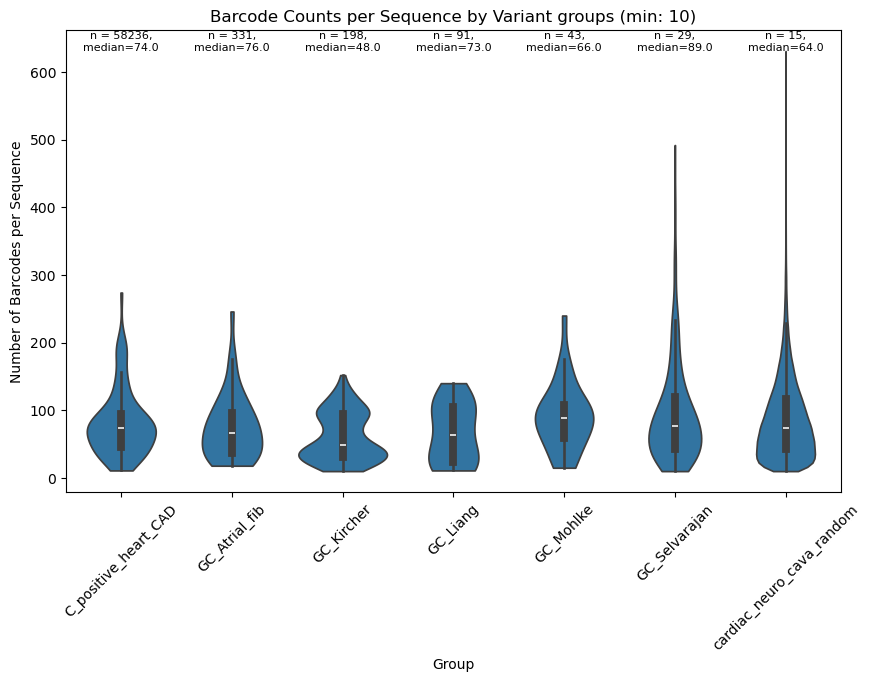

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample dataframe setup (replace this with your actual dataframe)
# df = pd.DataFrame({
#     'name': [...], 'Barcode': [...], 'tmp_label': [...],
#     'dna1': [...], 'rna1': [...], 'dna2': [...], 'rna2': [...],
#     'dna3': [...], 'rna3': [...]
# })

# Count unique barcodes per sequence
barcode_counts = variant_result_bbmap_mapq10_counts_df.groupby('name')['Barcode'].nunique().reset_index()
barcode_counts.columns = ['name', 'barcode_count']

# Merge this count back to the main dataframe to keep group information
df = variant_result_bbmap_mapq10_counts_df.merge(barcode_counts, on='name')

# Now group by 'tmp_label' to prepare for the violin plot
# This will have one row per sequence with barcode counts and tmp_label
grouped = df[['name', 'tmp_label', 'barcode_count']].drop_duplicates()
# Calculate median barcode count per group
median_counts = grouped.groupby('tmp_label')['barcode_count'].median()
min_counts = grouped.groupby('tmp_label')['barcode_count'].min()
mean_counts = grouped.groupby('tmp_label')['barcode_count'].mean()

# Plot the violin plot with boxplots
plt.figure(figsize=(10, 6))
sns.violinplot(data=grouped, x='tmp_label', y='barcode_count', inner="box", cut=0)

# Annotate with number of sequences per group
for idx, (label, count) in enumerate(grouped['tmp_label'].value_counts().items()):
    median = median_counts[label]
    plt.text(x=idx, y=grouped['barcode_count'].max() + 1,
             s=f'n = {count},\nmedian={median:.1f}',
             ha='center', fontsize=8, color="black")

plt.xticks(rotation=45)

plt.xlabel("Group")
plt.ylabel("Number of Barcodes per Sequence")
plt.title("Barcode Counts per Sequence by Variant groups (min: 10)")
plt.show()


In [65]:
median_counts
min_counts
# mean_counts

tmp_label
C_positive_heart_CAD         11
GC_Atrial_fib                18
GC_Kircher                   10
GC_Liang                     11
GC_Mohlke                    15
GC_Selvarajan                10
cardiac_neuro_cava_random    10
Name: barcode_count, dtype: int64